# 02 — Process Performance Map (Camargo BPIC17)

Port of the henryk `02_process_performance_map` notebook, adapted for the Camargo `FullShared_Join_LSTM` baseline trained with the **paper-faithful n-gram=15 loader** (see `train_camargo_LSTM_ngram15.ipynb`). The earlier U-ED-LSTM-style windowing gave the model mostly EOS targets and no signal at short prefixes — this variant emits one training sample per time-step with the actual next activity as target.

- **Node label**: activity; color ∝ overall per-source-activity accuracy.
- **Edge label**: `correct / total` predictions for that directly-follows transition.
- **Edge color**: per-transition accuracy (green = high, red = low).

The Camargo model is a single-step next-activity predictor; we iterate prefixes (length 1..L-1) and call it once per prefix to build the performance map.

In [1]:
import sys
from pathlib import Path

# Locate project root and add needed paths
_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir() and (_current / 'encoded_data').is_dir():
        break
    _current = _current.parent
_camargo_dir = _current / 'src' / 'interpretability' / 'notebooks' / 'camargo'
for p in [_current, _current / 'src', _camargo_dir]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import _camargo_utils as utils

project_root = _current
SPEC = utils.BPIC17_NGRAM

model = utils.load_camargo_model(project_root, SPEC)
dataset = utils.load_test_dataset(project_root, SPEC)
# With ngram_size set, use that at inference so the input shape matches training.
window = SPEC.ngram_size or utils.compute_window(dataset)
predictor = utils.CamargoPredictor(model, SPEC, window)
print(f'Loaded Camargo {SPEC.name} model | window={window} | vocab={predictor.n_classes} classes | |test|={len(dataset)}')

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'User_111': 16, 'User_112': 17, 'User_113': 18, 'User_114': 19, 'User_115': 20, 'User_116': 21, 'User_117

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Loaded Camargo BPIC17 (n-gram=15) model | window=15 | vocab=28 classes | |test|=253196


In [2]:
records = utils.collect_prefix_predictions(predictor, dataset, progress=True, include_end=True)
print(f'Collected {len(records)} prefix predictions')
print(f"Overall accuracy: {sum(r['correct'] for r in records) / len(records) * 100:.1f}%")

IndexError: list index out of range

In [ ]:
# --- Overall accuracy summary ---
from collections import defaultdict
import pandas as pd

n_total = len(records)
n_correct = sum(1 for r in records if r['correct'])
overall = n_correct / n_total if n_total else 0.0
print(f'Overall next-activity accuracy: {n_correct}/{n_total} = {overall:.4f} ({overall*100:.2f}%)')

by_plen = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    by_plen[r['prefix_length']]['total'] += 1
    by_plen[r['prefix_length']]['correct'] += int(r['correct'])
rows = [{'prefix_length': pl, 'correct': v['correct'], 'total': v['total'],
         'accuracy': v['correct'] / v['total']}
        for pl, v in sorted(by_plen.items())]
print('\nPer prefix-length:')
print(pd.DataFrame(rows).to_string(index=False))

if n_total and 'confidence' in records[0]:
    mean_conf = sum(r['confidence'] for r in records) / n_total
    print(f'\nMean top-1 confidence: {mean_conf*100:.2f}%')


Overall next-activity accuracy: 211511/233418 = 0.9061 (90.61%)

Per prefix-length:
 prefix_length  correct  total  accuracy
             1     5696   6301  0.903983
             2     6301   6301  1.000000
             3     6301   6301  1.000000
             4     6031   6301  0.957150
             5     5917   6301  0.939057
             6     5732   6301  0.909697
             7     4892   6301  0.776385
             8     5382   6301  0.854150
             9     5613   6301  0.890811
            10     5582   6296  0.886595
            11     5785   6293  0.919275
            12     5898   6290  0.937679
            13     5854   6285  0.931424
            14     6006   6283  0.955913
            15     5708   6277  0.909352
            16     5991   6262  0.956723
            17     5873   6254  0.939079
            18     5470   5991  0.913036
            19     5494   5951  0.923206
            20     5471   5820  0.940034
            21     4991   5575  0.895247
            22

In [ ]:
import pandas as pd
from collections import defaultdict

# Per-transition stats (source activity, actual next activity) -> total / correct
stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    key = (r['current_activity'], r['actual_next_activity'])
    stats[key]['total'] += 1
    stats[key]['correct'] += int(r['correct'])

# Per-source accuracy (node color)
node_stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    node_stats[r['current_activity']]['total'] += 1
    node_stats[r['current_activity']]['correct'] += int(r['correct'])

rows = []
for (src, tgt), s in stats.items():
    rows.append({'source': src, 'target': tgt, 'correct': s['correct'], 'total': s['total'],
                 'accuracy': s['correct'] / s['total']})
transitions_df = pd.DataFrame(rows).sort_values(['source', 'total'], ascending=[True, False])
print(f'{len(transitions_df)} unique transitions')
with pd.option_context('display.max_rows', None):
    display(transitions_df)

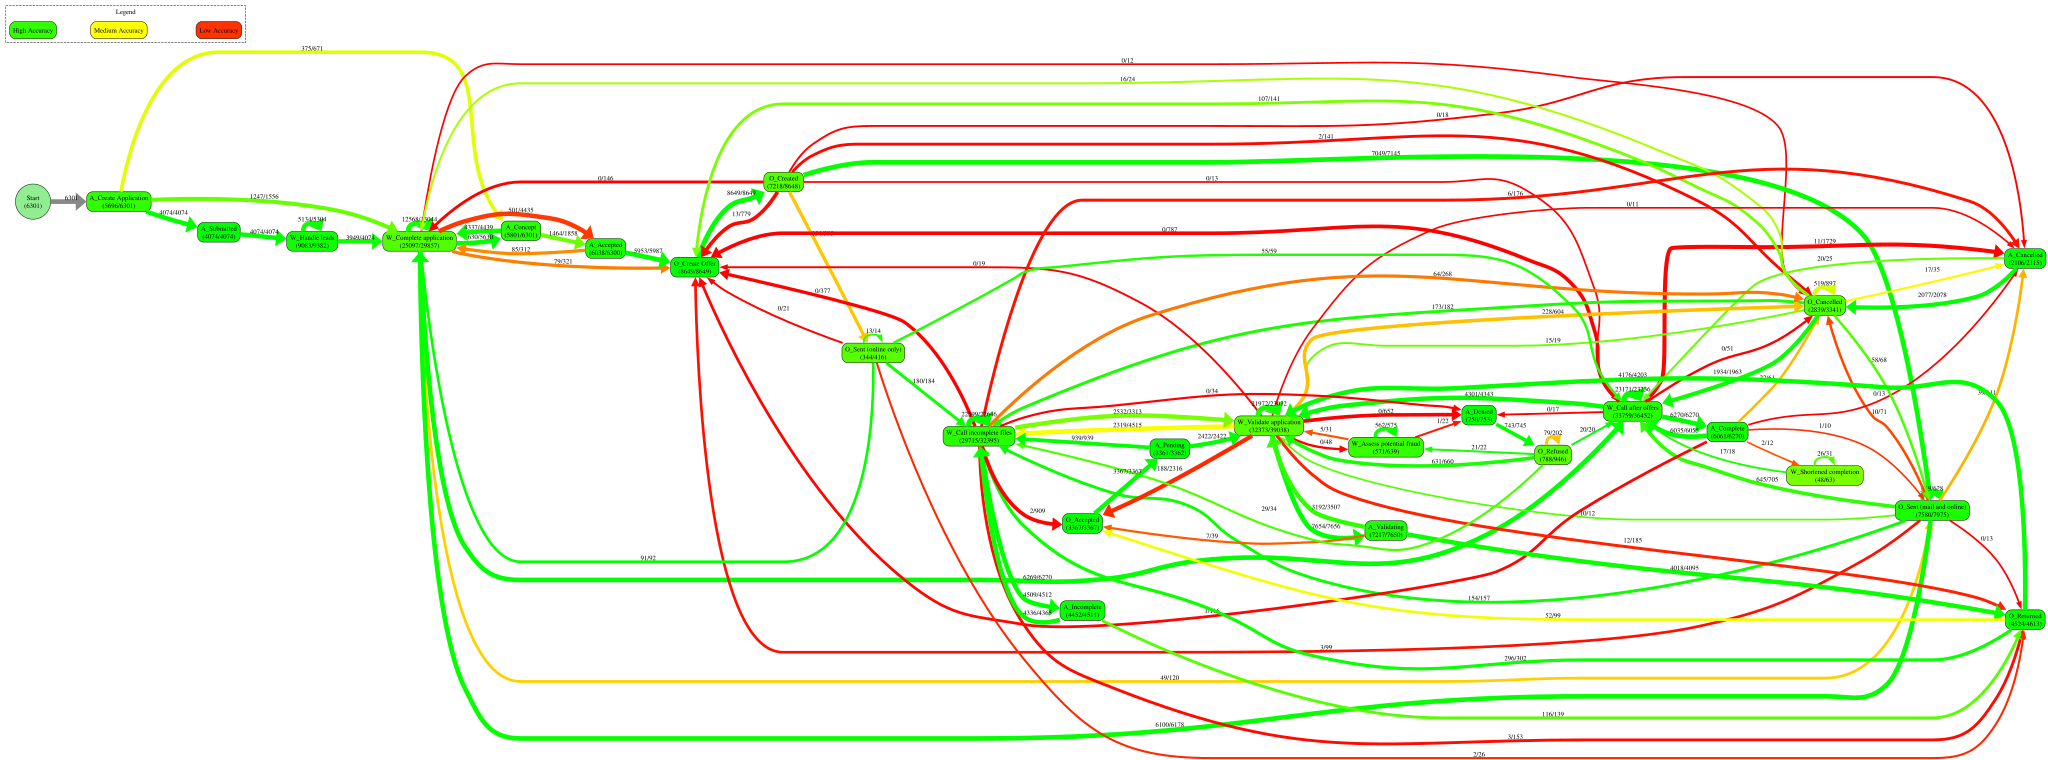

In [ ]:
import graphviz
import math

MIN_EDGE_COUNT = 10

def get_color_for_accuracy(accuracy: float) -> str:
    """Red (low) -> Yellow (mid) -> Green (high) gradient -- same as henryk/process_performance_map."""
    if accuracy < 0.5:
        r = 255
        g = int(255 * (accuracy * 2))
        b = 0
    else:
        r = int(255 * (1 - (accuracy - 0.5) * 2))
        g = 255
        b = 0
    return f'#{r:02x}{g:02x}{b:02x}'


dot = graphviz.Digraph(comment=f'Camargo {SPEC.name} Process Performance Map')
dot.attr(rankdir='LR')
dot.attr('node', shape='box', style='rounded,filled', fillcolor='white')

for act, s in node_stats.items():
    if s['total'] > 0:
        acc = s['correct'] / s['total']
        label = f"{act}\n({s['correct']}/{s['total']})"
        fill = get_color_for_accuracy(acc)
    else:
        label = str(act)
        fill = 'white'
    dot.node(str(act), label=label, fillcolor=fill)

start_counts = {}
for r in records:
    if r['prefix_length'] == 1:
        start_counts[r['current_activity']] = start_counts.get(r['current_activity'], 0) + 1
total_cases = sum(start_counts.values())
if total_cases:
    dot.node('__START__', label=f'Start\n({total_cases})', shape='circle', fillcolor='#90EE90', style='filled')
    for act, cnt in start_counts.items():
        if cnt >= MIN_EDGE_COUNT:
            dot.edge('__START__', str(act), label=str(cnt), color='#888888',
                     penwidth=str(1 + math.log1p(cnt)))

for (src, tgt), s in stats.items():
    if s['total'] < MIN_EDGE_COUNT:
        continue
    acc = s['correct'] / s['total']
    color = get_color_for_accuracy(acc)
    label = f"{s['correct']}/{s['total']}"
    dot.edge(str(src), str(tgt), label=label, color=color,
             penwidth=str(1 + math.log1p(s['total'])))

with dot.subgraph(name='cluster_legend') as legend:
    legend.attr(label='Legend', style='dashed')
    legend.node('high_acc', 'High Accuracy', fillcolor=get_color_for_accuracy(0.9))
    legend.node('mid_acc', 'Medium Accuracy', fillcolor=get_color_for_accuracy(0.5))
    legend.node('low_acc', 'Low Accuracy', fillcolor=get_color_for_accuracy(0.1))
    legend.edge('high_acc', 'mid_acc', style='invis')
    legend.edge('mid_acc', 'low_acc', style='invis')

dot

In [ ]:
# Per-source summary
print('Per-source-activity accuracy:')
for act, s in sorted(node_stats.items(), key=lambda x: -x[1]['total']):
    acc = s['correct'] / s['total']
    print(f"  {act:<30s} {s['correct']:5d}/{s['total']:<5d}  {acc * 100:5.1f}%")

Per-source-activity accuracy:
  W_Validate application         32373/39038   82.9%
  W_Call after offers            33759/36452   92.6%
  W_Call incomplete files        29715/32395   91.7%
  W_Complete application         25097/29857   84.1%
  W_Handle leads                  9083/9382    96.8%
  O_Create Offer                  8649/8649   100.0%
  O_Created                       7218/8648    83.5%
  O_Sent (mail and online)        7580/7975    95.0%
  A_Validating                    7217/7650    94.3%
  A_Create Application            5696/6301    90.4%
  A_Concept                       5801/6301    92.1%
  A_Accepted                      6038/6300    95.8%
  A_Complete                      6061/6270    96.7%
  O_Returned                      4524/4613    98.1%
  A_Incomplete                    4452/4511    98.7%
  A_Submitted                     4074/4074   100.0%
  O_Accepted                      3367/3367   100.0%
  A_Pending                       3361/3362   100.0%
  O_Cancelled   